In [ ]:
!unzip "archive (1).zip"

Archive:  archive (1).zip
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00003690.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00009052.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00011152.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00012460.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00017380.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00019830.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00022292.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00025912.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00027492.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00028540.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00029381.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00029691.JPEG  
  

In [ ]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "imagewoof200"

In [ ]:
import os
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


In [ ]:
check_data(image_path)

There are 2 directories and 0 images in 'imagewoof200'.
There are 10 directories and 0 images in 'imagewoof200/test'.
There are 0 directories and 48 images in 'imagewoof200/test/samoyed'.
There are 0 directories and 48 images in 'imagewoof200/test/australian_terrier'.
There are 0 directories and 48 images in 'imagewoof200/test/golden_retriever'.
There are 0 directories and 48 images in 'imagewoof200/test/dingo'.
There are 0 directories and 48 images in 'imagewoof200/test/english_foxhound'.
There are 0 directories and 48 images in 'imagewoof200/test/old_english_sheepdog'.
There are 0 directories and 48 images in 'imagewoof200/test/rhodesian_ridgeback'.
There are 0 directories and 48 images in 'imagewoof200/test/beagle'.
There are 0 directories and 48 images in 'imagewoof200/test/border_terrier'.
There are 0 directories and 48 images in 'imagewoof200/test/shih_tzu'.
There are 10 directories and 0 images in 'imagewoof200/train'.
There are 0 directories and 200 images in 'imagewoof200/trai

In [ ]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
from torchvision.transforms import v2
import torch

train_transforms = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), antialias=True), # Çok fazla kırpmamak için scale dar tutuldu
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05), # Hue çok düşük
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet standartları
    v2.RandomErasing(p=0.1) # Modele zorluk katmak için opsiyonel
])


# TEST / VALIDATION PIPELINE
test_transforms = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True), # Pikselleri [0.0, 1.0] arasına çeker
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
def create_dataloaders(
    train_dir: str,
    test_dir: str,
    train_transforms: transforms.Compose,
    test_transforms: transforms.Compose,
    batch_size: int,
    num_workers: int=os.cpu_count()
):

  train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
  test_data = datasets.ImageFolder(test_dir, transform=test_transforms)
  class_names = train_data.classes


  train_dataloader = DataLoader(train_data,
                                batch_size=batch_size,
                                shuffle=True,
                                num_workers=num_workers,
                                pin_memory=True)

  test_dataloader = DataLoader(test_data,
                                batch_size=batch_size,
                                shuffle=False,
                                num_workers=num_workers,
                                pin_memory=True)

  return train_dataloader, test_dataloader, class_names


In [ ]:
train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=train_dir,
                                                                    test_dir=test_dir,
                                                                    train_transforms=train_transforms,
                                                                    test_transforms=test_transforms,
                                                                    batch_size=32)

In [ ]:
class_names

['australian_terrier',
 'beagle',
 'border_terrier',
 'dingo',
 'english_foxhound',
 'golden_retriever',
 'old_english_sheepdog',
 'rhodesian_ridgeback',
 'samoyed',
 'shih_tzu']

In [ ]:
import torchvision
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

In [ ]:
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [ ]:
auto_transforms = weights.transforms()

In [ ]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [ ]:
train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=train_dir,
                                                                    test_dir=test_dir,
                                                                    train_transforms=auto_transforms,
                                                                    test_transforms=auto_transforms,
                                                                    batch_size=32)

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [ ]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
summary(model, input_size=(32, 3, 224, 224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 1000]                --
├─Sequential: 1-1                                       [32, 1280, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 112, 112]        864
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        64
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        --
│    └─Sequential: 2-2                                  [32, 16, 112, 112]        --
│    │    └─MBConv: 3-4                                 [32, 16, 112, 112]        1,448
│    └─Sequential: 2-3                                  [32, 24, 56, 56]          --
│    │    └─MBConv: 3-5                                 [32, 24, 56, 56]          6,004
│    │    └─MBConv: 3-6                              

In [ ]:
for param in model.features.parameters():
  param.requires_grad = False

In [ ]:
output_shape = len(class_names)

In [ ]:
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=output_shape, bias=True)
).to(device)

In [ ]:
summary(model, input_size=(32, 3, 224, 224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 10]                  --
├─Sequential: 1-1                                       [32, 1280, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 112, 112]        (864)
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        (64)
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        --
│    └─Sequential: 2-2                                  [32, 16, 112, 112]        --
│    │    └─MBConv: 3-4                                 [32, 16, 112, 112]        (1,448)
│    └─Sequential: 2-3                                  [32, 24, 56, 56]          --
│    │    └─MBConv: 3-5                                 [32, 24, 56, 56]          (6,004)
│    │    └─MBConv: 3-6                      

In [ ]:
from torch import nn

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 1. Adım: Cihazı dinamik olarak seç (GPU varsa cuda, yoksa cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Çalışan Cihaz: {device}")

# 2. Adım: Model ve Loss fonksiyonunu seçilen cihaza gönder
model = model.to(device)
loss_fn = loss_fn.to(device)

# --- Mevcut Kodunun Başlangıcı ---
torch.manual_seed(42)

num_epochs = 10

train_loss = []
test_loss = []
train_accuracy = []
test_accuracy = []

for epoch in range(num_epochs):
    print(f"Epoch: {epoch + 1}\n---------")

    epoch_train_loss = 0
    epoch_train_acc = 0

    model.train()

    for batch, (X, y) in enumerate(train_dataloader):
        # 3. Adım: Eğitim verilerini ve etiketlerini GPU'ya taşı
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)

        # Loss
        loss = loss_fn(y_pred, y)
        epoch_train_loss += loss.item()

        # Optimizer
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accuracy
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        acc = (y_pred_class == y).sum().item() / len(y)
        epoch_train_acc += acc

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

    epoch_train_loss /= len(train_dataloader)
    epoch_train_acc /= len(train_dataloader)

    epoch_test_loss = 0
    epoch_test_acc = 0

    model.eval()

    with torch.inference_mode():
        for X, y in test_dataloader:
            # 4. Adım: Test verilerini ve etiketlerini GPU'ya taşı
            X, y = X.to(device), y.to(device)

            # Forward pass
            test_pred = model(X)

            # Loss
            loss = loss_fn(test_pred, y)
            epoch_test_loss += loss.item()

            # Accuracy
            test_pred_class = torch.argmax(torch.softmax(test_pred, dim=1), dim=1)
            acc = (test_pred_class == y).sum().item() / len(y)
            epoch_test_acc += acc

    epoch_test_loss /= len(test_dataloader)
    epoch_test_acc /= len(test_dataloader)

    train_loss.append(epoch_train_loss)
    test_loss.append(epoch_test_loss)
    train_accuracy.append(epoch_train_acc)
    test_accuracy.append(epoch_test_acc)

    print(f"Train loss: {epoch_train_loss:.5f} | Train accuracy: {epoch_train_acc:.2%}")
    print(f"Test loss: {epoch_test_loss:.5f} | Test accuracy: {epoch_test_acc:.2%}\n")

Çalışan Cihaz: cuda
Epoch: 1
---------
Looked at 0/2000 samples.
Train loss: 1.37830 | Train accuracy: 68.60%
Test loss: 0.73768 | Test accuracy: 86.04%

Epoch: 2
---------
Looked at 0/2000 samples.
Train loss: 0.67295 | Train accuracy: 85.27%
Test loss: 0.51811 | Test accuracy: 88.12%

Epoch: 3
---------
Looked at 0/2000 samples.
Train loss: 0.53498 | Train accuracy: 87.05%
Test loss: 0.46372 | Test accuracy: 87.92%

Epoch: 4
---------
Looked at 0/2000 samples.
Train loss: 0.46274 | Train accuracy: 89.38%
Test loss: 0.40806 | Test accuracy: 89.58%

Epoch: 5
---------
Looked at 0/2000 samples.
Train loss: 0.40704 | Train accuracy: 89.63%
Test loss: 0.40820 | Test accuracy: 87.92%

Epoch: 6
---------
Looked at 0/2000 samples.
Train loss: 0.36735 | Train accuracy: 90.58%
Test loss: 0.38919 | Test accuracy: 88.33%

Epoch: 7
---------
Looked at 0/2000 samples.
Train loss: 0.34509 | Train accuracy: 90.58%
Test loss: 0.37746 | Test accuracy: 88.96%

Epoch: 8
---------
Looked at 0/2000 sample

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

from typing import List, Tuple

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

from typing import List, Tuple

def transform_predict(model: torch.nn.Module,
                      image_path: str,
                      class_names: List[str],
                      image_size: Tuple[int, int] = (224, 224),
                      transform=None,
                      device: torch.device = device):

  img = Image.open(image_path)

  if transform is not None:
    image_transform = transform
  else:
    image_transform = v2.Compose([
        v2.Resize(image_size),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])

  model.to(device)
  model.eval()
  with torch.inference_mode():
    target_image = image_transform(img).unsqueeze(dim=0)
    target_image_pred = model(target_image.to(device))

  target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
  plt.axis(False)

In [ ]:
custom_image_path = data_path / "istockphoto-455646273-612x612.jpg"

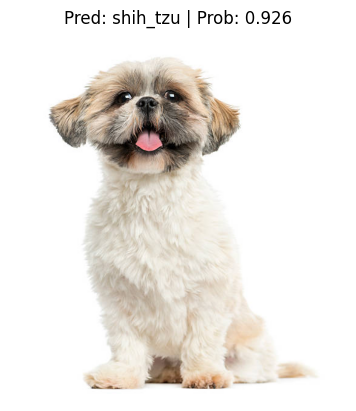

In [ ]:
transform_predict(model=model,
                  image_path=custom_image_path,
                  class_names=class_names,
                  transform=auto_transforms)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_dataloader: # test_loader ismin neyse onu yaz
        images = images.to(device)
        outputs = model(images)

        # En yüksek olasılıklı sınıfın indeksini al
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

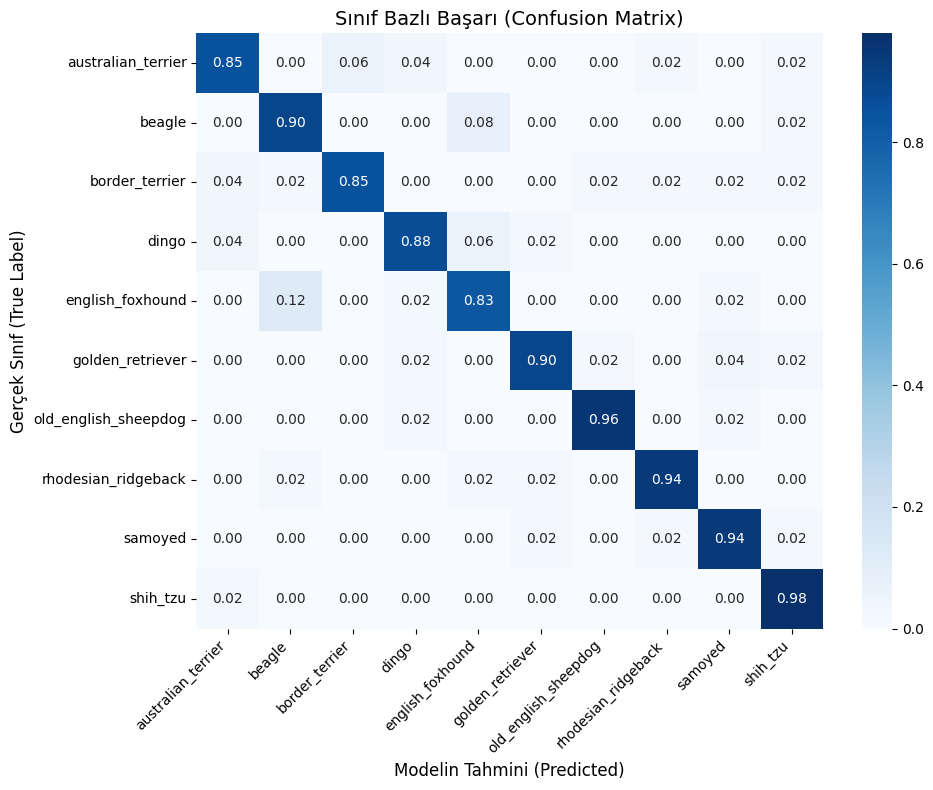

In [ ]:
# 1. Matrisi hesapla (Yüzdesel başarı görmek için normalize='true' yapıyoruz)
cm = confusion_matrix(y_true, y_pred, normalize='true')

# 2. Sınıf isimlerini al (imagewoof sınıfları)
class_names = class_names  # örn: ['beagle', 'golden_retriever', ...]

# 3. Görselleştirme
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,             # Hücrelerin içine oranları yaz
    fmt='.2f',              # Virgülden sonra 2 basamak göster (örn: 0.85)
    cmap='Blues',           # Renk paleti (Korelasyon matrisi görünümü)
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Sınıf Bazlı Başarı (Confusion Matrix)', fontsize=14)
plt.xlabel('Modelin Tahmini (Predicted)', fontsize=12)
plt.ylabel('Gerçek Sınıf (True Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: >

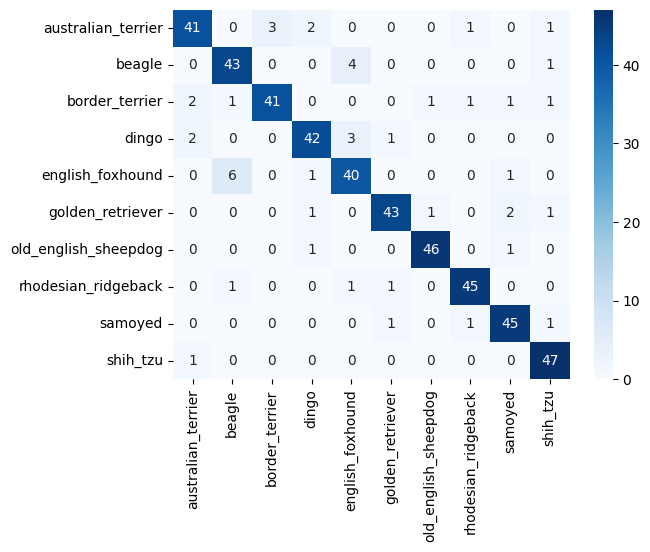

In [ ]:
# normalize='true' parametresini kaldırıp ham matrisi alıyoruz
cm_counts = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm_counts,
    annot=True,
    fmt='d', # Tam sayı (integer) formatı
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)